In [36]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import pydicom as dicom
import pandas as pd
import numpy as np
import optuna
from sklearn.model_selection import train_test_split
import skimage
import scipy

import cbis
import metrics
import unet

import matplotlib.pyplot as plt

In [54]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, target: torch.Tensor, pred: torch.Tensor):
        """
        pred: softmax probabilities, shape (B, 2, W, H)
        target: one-hot encoded masks, shape (B, 2, W, H)
        """
        intersection = (pred * target).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))

        dice = (2 * intersection + self.smooth) / (union + self.smooth)

        return (1 - dice).mean(), (1 - dice

In [55]:
class IndividualDiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, target: torch.Tensor, pred: torch.Tensor):
        """
        pred: softmax probabilities, shape (B, 2, W, H)
        target: one-hot encoded masks, shape (B, 2, W, H)
        """
        intersection = (pred * target).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))

        dice = (2 * intersection + self.smooth) / (union + self.smooth)

        return 1 - dice

In [56]:
shape = (3, 2, 128, 128)
t1 = torch.rand(shape)
t2 = torch.rand(shape)

In [62]:
IndividualDiceLoss()(t1, t2).mean()

tensor(0.4999)

In [58]:
DiceLoss()(t1, t2)

tensor(0.4999)

In [3]:
device = torch.device("xpu" if torch.xpu.is_available() else "cpu")

# path to the root folder of the data
ROOT_FILEPATH = "/run/media/gianluca/EXTERNAL_US/CBIS-DDSM"

lesions_df = pd.read_csv(f"{ROOT_FILEPATH}/lesions.csv")

# keeping only MLO and masses
lesions_df = lesions_df[
    (lesions_df["image view"] == "MLO") & 
    (lesions_df["kind"] == "Mass")
].head(10)

df_train_val, df_test = train_test_split(lesions_df, test_size=0.2,random_state=0)
df_train, df_val = train_test_split(df_train_val, test_size=0.25, random_state=0)

train_data = cbis.CBIS_Dataset(ROOT_FILEPATH, df_train)
validation_data = cbis.CBIS_Dataset(ROOT_FILEPATH, df_val)
test_data = cbis.CBIS_Dataset(ROOT_FILEPATH, df_test)

train_dataloader = DataLoader(train_data, batch_size=1, shuffle=True)
validation_dataloader = DataLoader(validation_data, batch_size=1, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=1, shuffle=True)

model = unet.UNet(n_class=2)
checkpoint = torch.load(
    "/home/gianluca/Desktop/model/20260616_095819/final_model/checkpoints/checkpoint_4.pth", 
    weights_only=True, 
    map_location=torch.device('cpu')
)
model.load_state_dict(checkpoint['model_state_dict'])

loss_fn = metrics.DiceLoss()

In [18]:
it = iter(train_dataloader)

In [19]:
X, y = next(it)

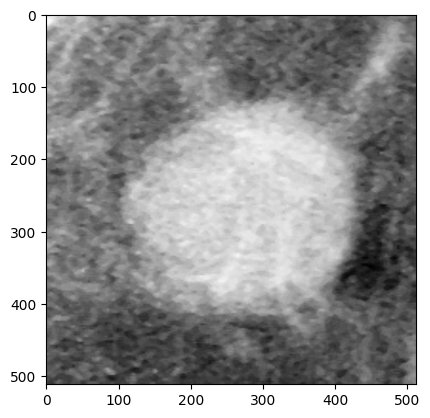

In [20]:
plt.imshow(X[0,0], cmap="gray")

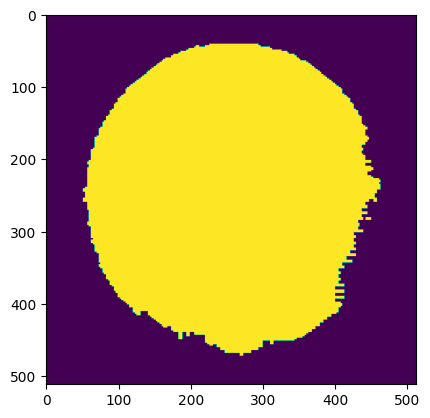

In [21]:
plt.imshow(y[0,1])

In [24]:
logits = model(X)
pred_probs = torch.softmax(logits, dim=1)
loss = loss_fn(y.float(), pred_probs).item()

In [25]:
loss

0.281943678855896

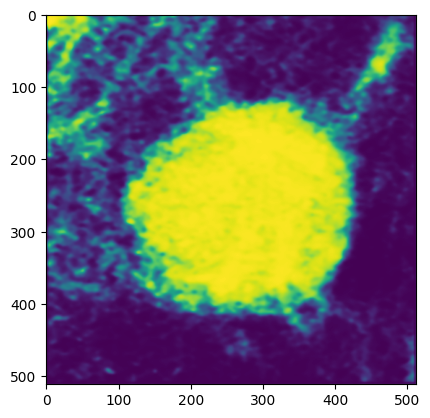

In [23]:
plt.imshow(pred_probs.detach()[0,1])

In [13]:
loss = loss_fn(y.float(), y.float())